### Sleep and Stress in Adult Population vs College Students Code

In [9]:
# requriede imports
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [10]:
# loading in the sleep dataset, downloading as a CSV 
sleep = pd.read_csv('/Users/sarakoshy/Downloads/Student Insomnia and Educational Outcomes Dataset.csv')

In [11]:
# first 10 rows of sleep df 
sleep.head(10)

,Timestamp,1. What is your year of study?,2. What is your gender?,3. How often do you have difficulty falling asleep at night?,"4. On average, how many hours of sleep do you get on a typical day?",5. How often do you wake up during the night and have trouble falling back asleep?,6. How would you rate the overall quality of your sleep?,7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?,"8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?","9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?",10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?,"11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?","12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?",13. How often do you engage in physical activity or exercise?,14. How would you describe your stress levels related to academic workload?,15. How would you rate your overall academic performance (GPA or grades) in the past semester?
0,10/24/2024 16:51:15,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Sometimes,Often,Often (3-4 times a week),Moderate impact,Often (5-6 times a week),Rarely (1-2 times a week),Sometimes (3-4 times a week),High stress,Average
1,10/24/2024 16:51:51,Third year,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Often,Sometimes,Sometimes (1-2 times a week),Major impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Sometimes (3-4 times a week),Low stress,Good
2,10/24/2024 16:52:21,First year,Female,Sometimes (3-4 times a week),7-8 hours,Sometimes (3-4 times a week),Good,Often,Often,Sometimes (1-2 times a week),Major impact,Often (5-6 times a week),Often (5-6 times a week),Often (5-6 times a week),High stress,Below Average
3,10/24/2024 16:53:00,Third year,Male,Often (5-6 times a week),More than 8 hours,Sometimes (3-4 times a week),Poor,Often,Often,Rarely (1-2 times a month),Minor impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Every day,Extremely high stress,Excellent
4,10/24/2024 16:53:25,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Very good,Always,Sometimes,Sometimes (1-2 times a week),Moderate impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Often (5-6 times a week),Low stress,Average
5,10/24/2024 16:53:53,Second year,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Very good,Sometimes,Rarely,Sometimes (1-2 times a week),Minor impact,Sometimes (3-4 times a week),Often (5-6 times a week),Rarely (1-2 times a week),High stress,Below Average
6,10/24/2024 16:54:24,Third year,Male,Sometimes (3-4 times a week),7-8 hours,Often (5-6 times a week),Good,Sometimes,Often,Sometimes (1-2 times a week),Minor impact,Rarely (1-2 times a week),Rarely (1-2 times a week),Never,No stress,Good
7,10/24/2024 16:54:50,Third year,Male,Often (5-6 times a week),More than 8 hours,Every night,Good,Always,Sometimes,Often (3-4 times a week),Moderate impact,Often (5-6 times a week),Rarely (1-2 times a week),Rarely (1-2 times a week),Low stress,Good
8,10/24/2024 16:55:18,Third year,Male,Often (5-6 times a week),More than 8 hours,Often (5-6 times a week),Average,Sometimes,Rarely,Rarely (1-2 times a month),Moderate impact,Rarely (1-2 times a week),Rarely (1-2 times a week),Sometimes (3-4 times a week),Extremely high stress,Average
9,10/24/2024 16:56:33,Third year,Male,Every night,More than 8 hours,Every night,Very good,Always,Always,Always,Moderate impact,Often (5-6 times a week),Sometimes (3-4 times a week),Often (5-6 times a week),High stress,Poor


### Visualizing the Data


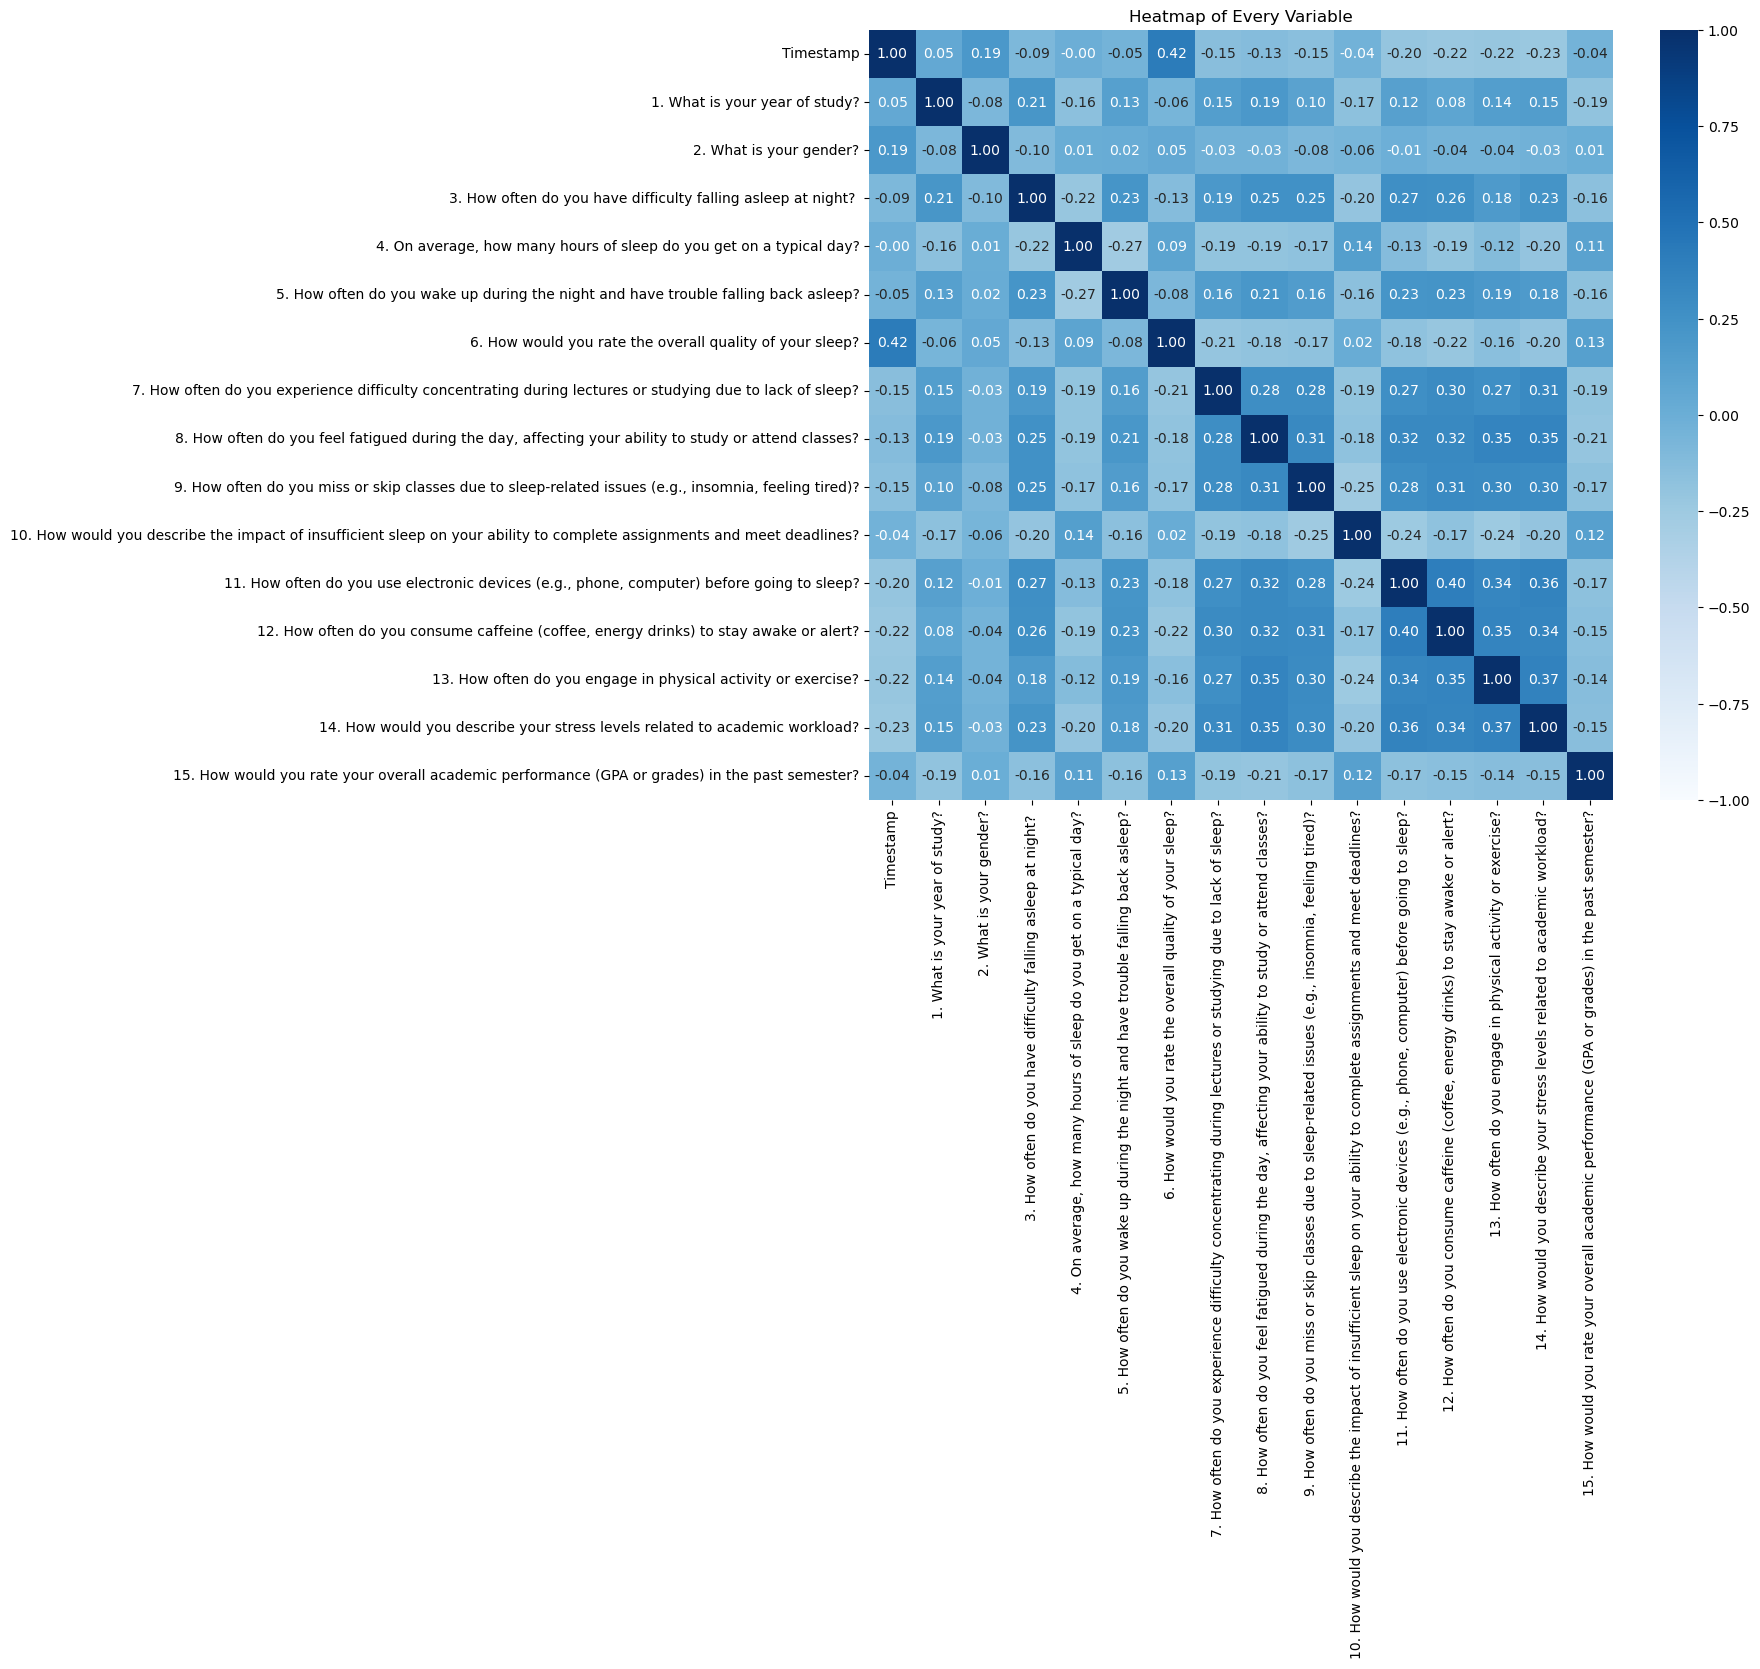

In [12]:
# heatmap of every variable
sleep_copy = sleep.copy()
# eoncoding categorical vars 
le = LabelEncoder()
for col in sleep_copy.columns:
    sleep_copy[col] = le.fit_transform(sleep_copy[col].astype(str))

# calculating correlation mat 
corr = sleep_copy.corr()

# plotting heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, vmin=-1, vmax=1, cmap="Blues", annot=True, fmt=".2f")

# title of visual
plt.title("Heatmap of Every Variable")
plt.show()

### Pre-processing data for visulization 

In [13]:
### checking data to make sure it isn't skewed, same number of male and females
gender_counts = sleep.iloc[:,2].value_counts().to_frame().T
gender_counts

2. What is your gender?,Male,Female
count,572,219


In [14]:
# there is more males than females so need to have the same number of males and females
# normilizing the data so same number of men and women to avoid skewing the eda 

# splittign by gender 
men = sleep[sleep.iloc[:,2] == "Male"]
women = sleep[sleep.iloc[:,2] == "Female"]

# sampling 219 men
men_sample = men.sample(n=219, random_state=1)

# new df with same number of males and females
sleep_normalized = pd.concat([women, men_sample])
sleep_normalized = sleep_normalized.reset_index(drop=True)
sleep_normalized.head(10)

,Timestamp,1. What is your year of study?,2. What is your gender?,3. How often do you have difficulty falling asleep at night?,"4. On average, how many hours of sleep do you get on a typical day?",5. How often do you wake up during the night and have trouble falling back asleep?,6. How would you rate the overall quality of your sleep?,7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?,"8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?","9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?",10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?,"11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?","12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?",13. How often do you engage in physical activity or exercise?,14. How would you describe your stress levels related to academic workload?,15. How would you rate your overall academic performance (GPA or grades) in the past semester?
0,10/24/2024 16:52:21,First year,Female,Sometimes (3-4 times a week),7-8 hours,Sometimes (3-4 times a week),Good,Often,Often,Sometimes (1-2 times a week),Major impact,Often (5-6 times a week),Often (5-6 times a week),Often (5-6 times a week),High stress,Below Average
1,10/24/2024 16:57:04,Second year,Female,Often (5-6 times a week),7-8 hours,Every night,Poor,Often,Sometimes,Always,Major impact,Sometimes (3-4 times a week),Often (5-6 times a week),Sometimes (3-4 times a week),High stress,Average
2,10/24/2024 16:59:52,Second year,Female,Often (5-6 times a week),6-7 hours,Sometimes (3-4 times a week),Good,Often,Sometimes,Sometimes (1-2 times a week),Major impact,Sometimes (3-4 times a week),Often (5-6 times a week),Sometimes (3-4 times a week),High stress,Below Average
3,10/24/2024 17:08:59,Second year,Female,Often (5-6 times a week),More than 8 hours,Often (5-6 times a week),Good,Sometimes,Often,Often (3-4 times a week),Minor impact,Often (5-6 times a week),Rarely (1-2 times a week),Often (5-6 times a week),High stress,Below Average
4,10/24/2024 17:12:15,Second year,Female,Often (5-6 times a week),7-8 hours,Every night,Average,Often,Rarely,Often (3-4 times a week),Moderate impact,Sometimes (3-4 times a week),Often (5-6 times a week),Sometimes (3-4 times a week),High stress,Good
5,10/24/2024 17:12:40,Second year,Female,Sometimes (3-4 times a week),7-8 hours,Often (5-6 times a week),Good,Often,Sometimes,Often (3-4 times a week),Major impact,Rarely (1-2 times a week),Often (5-6 times a week),Often (5-6 times a week),Low stress,Average
6,10/24/2024 17:15:43,Third year,Female,Often (5-6 times a week),7-8 hours,Sometimes (3-4 times a week),Average,Sometimes,Always,Often (3-4 times a week),Moderate impact,Often (5-6 times a week),Rarely (1-2 times a week),Often (5-6 times a week),Low stress,Good
7,10/24/2024 17:17:51,Graduate student,Female,Every night,7-8 hours,Often (5-6 times a week),Good,Often,Always,Often (3-4 times a week),Major impact,Often (5-6 times a week),Often (5-6 times a week),Often (5-6 times a week),High stress,Below Average
8,10/24/2024 17:18:37,Second year,Female,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Sometimes,Often,Sometimes (1-2 times a week),Moderate impact,Often (5-6 times a week),Sometimes (3-4 times a week),Often (5-6 times a week),High stress,Average
9,10/24/2024 17:20:38,Third year,Female,Often (5-6 times a week),7-8 hours,Sometimes (3-4 times a week),Average,Sometimes,Often,Rarely (1-2 times a month),Major impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Sometimes (3-4 times a week),Low stress,Average


In [15]:
# checkign to make sure data is normalized 
gender_counts = sleep_normalized.iloc[:,2].value_counts().to_frame().T
gender_counts

2. What is your gender?,Female,Male
count,219,219


### Gender vs Difficulty Sleeping 

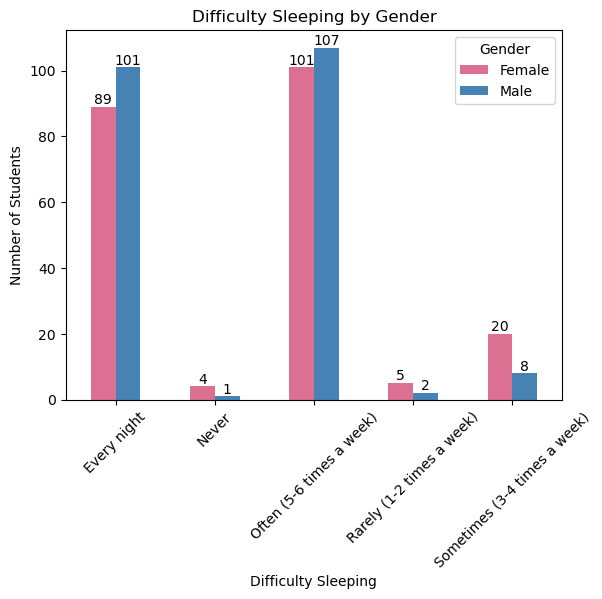

In [16]:
# selecting cols
gender = sleep_normalized.iloc[:,2]
diff = sleep_normalized.iloc[:,3]

# new df with cols 
df = pd.DataFrame({
    "Gender": gender,
    "Difficulty": diff
})

# counting number of students
counts = df.groupby(["Difficulty","Gender"]).size().unstack()

# plotting
ax = counts.plot(kind="bar", color=["palevioletred","steelblue"])
# adding labels
for c in ax.containers:
    ax.bar_label(c)

# axis labels and title
plt.xlabel("Difficulty Sleeping")
plt.ylabel("Number of Students")
plt.title("Difficulty Sleeping by Gender")
plt.xticks(rotation=45)

plt.show()

### Gender vs Hours Slept

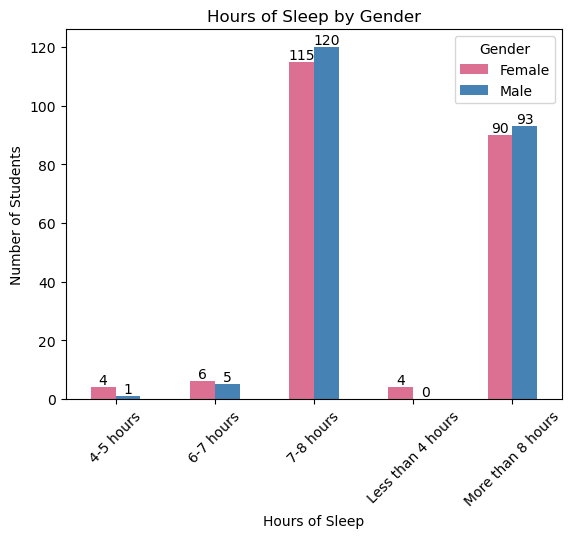

In [17]:
# selecting cols

gender = sleep_normalized.iloc[:,2]
hours = sleep_normalized.iloc[:,4]

# new df with cols 
df = pd.DataFrame({
    "Gender": gender,
    "Hours": hours
})

# counting number of students
counts = df.groupby(["Hours","Gender"]).size().unstack()

# plotting
ax = counts.plot(kind="bar", color=["palevioletred", "steelblue"])
# adding labels
for c in ax.containers:
    ax.bar_label(c)
    
# axis labels and title
plt.xlabel("Hours of Sleep")
plt.ylabel("Number of Students")
plt.title("Hours of Sleep by Gender")
plt.xticks(rotation=45)

plt.show()

### Gender vs Quality of Sleep

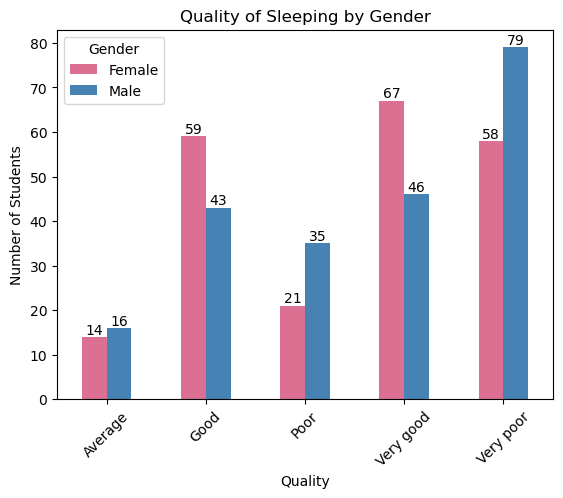

In [18]:
# selecting cols
gender = sleep_normalized.iloc[:,2]
quality = sleep_normalized.iloc[:,6]

# new df with cols
df = pd.DataFrame({
    "Gender": gender,
    "Quality": quality
})

# counting number of students
counts = df.groupby(["Quality","Gender"]).size().unstack()

# plotting
ax = counts.plot(kind="bar", color=["palevioletred", "steelblue"])
# adding labels
for c in ax.containers:
    ax.bar_label(c)
    
# axis labels and title
plt.xlabel("Quality")
plt.ylabel("Number of Students")
plt.title("Quality of Sleeping by Gender")
plt.xticks(rotation=45)

plt.show()

In [19]:
sleep.head(10)

,Timestamp,1. What is your year of study?,2. What is your gender?,3. How often do you have difficulty falling asleep at night?,"4. On average, how many hours of sleep do you get on a typical day?",5. How often do you wake up during the night and have trouble falling back asleep?,6. How would you rate the overall quality of your sleep?,7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?,"8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?","9. How often do you miss or skip classes due to sleep-related issues (e.g., insomnia, feeling tired)?",10. How would you describe the impact of insufficient sleep on your ability to complete assignments and meet deadlines?,"11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?","12. How often do you consume caffeine (coffee, energy drinks) to stay awake or alert?",13. How often do you engage in physical activity or exercise?,14. How would you describe your stress levels related to academic workload?,15. How would you rate your overall academic performance (GPA or grades) in the past semester?
0,10/24/2024 16:51:15,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Sometimes,Often,Often (3-4 times a week),Moderate impact,Often (5-6 times a week),Rarely (1-2 times a week),Sometimes (3-4 times a week),High stress,Average
1,10/24/2024 16:51:51,Third year,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Often,Sometimes,Sometimes (1-2 times a week),Major impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Sometimes (3-4 times a week),Low stress,Good
2,10/24/2024 16:52:21,First year,Female,Sometimes (3-4 times a week),7-8 hours,Sometimes (3-4 times a week),Good,Often,Often,Sometimes (1-2 times a week),Major impact,Often (5-6 times a week),Often (5-6 times a week),Often (5-6 times a week),High stress,Below Average
3,10/24/2024 16:53:00,Third year,Male,Often (5-6 times a week),More than 8 hours,Sometimes (3-4 times a week),Poor,Often,Often,Rarely (1-2 times a month),Minor impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Every day,Extremely high stress,Excellent
4,10/24/2024 16:53:25,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Very good,Always,Sometimes,Sometimes (1-2 times a week),Moderate impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Often (5-6 times a week),Low stress,Average
5,10/24/2024 16:53:53,Second year,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Very good,Sometimes,Rarely,Sometimes (1-2 times a week),Minor impact,Sometimes (3-4 times a week),Often (5-6 times a week),Rarely (1-2 times a week),High stress,Below Average
6,10/24/2024 16:54:24,Third year,Male,Sometimes (3-4 times a week),7-8 hours,Often (5-6 times a week),Good,Sometimes,Often,Sometimes (1-2 times a week),Minor impact,Rarely (1-2 times a week),Rarely (1-2 times a week),Never,No stress,Good
7,10/24/2024 16:54:50,Third year,Male,Often (5-6 times a week),More than 8 hours,Every night,Good,Always,Sometimes,Often (3-4 times a week),Moderate impact,Often (5-6 times a week),Rarely (1-2 times a week),Rarely (1-2 times a week),Low stress,Good
8,10/24/2024 16:55:18,Third year,Male,Often (5-6 times a week),More than 8 hours,Often (5-6 times a week),Average,Sometimes,Rarely,Rarely (1-2 times a month),Moderate impact,Rarely (1-2 times a week),Rarely (1-2 times a week),Sometimes (3-4 times a week),Extremely high stress,Average
9,10/24/2024 16:56:33,Third year,Male,Every night,More than 8 hours,Every night,Very good,Always,Always,Always,Moderate impact,Often (5-6 times a week),Sometimes (3-4 times a week),Often (5-6 times a week),High stress,Poor


### Fatigue during the day and difficulty concentrating due to sleep 

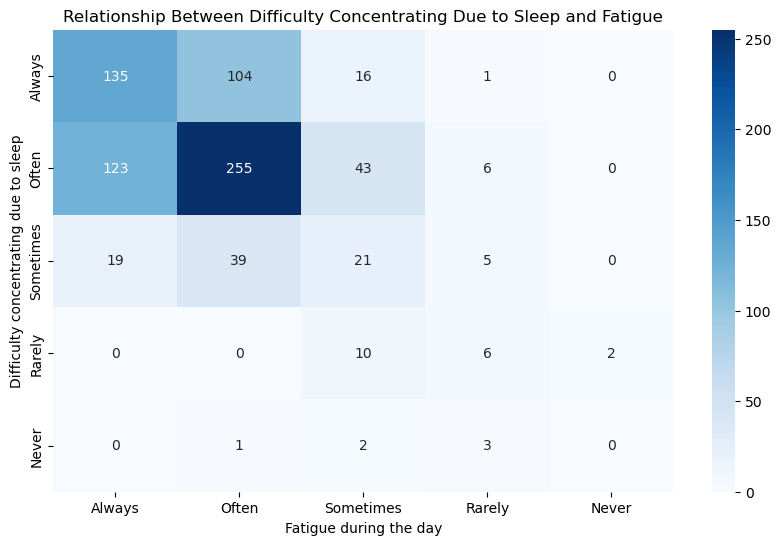

In [20]:
# heatmap between fatigue and difficulty concetraing 
# ordering reponse options
order = ["Always", "Often", "Sometimes", "Rarely", "Never"]

# picking cols 
cols = [
    "7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?",
    "8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?"
]

# converting to categorical 
sleep[cols[0]] = pd.Categorical(sleep[cols[0]], categories=order, ordered=True)
sleep[cols[1]] = pd.Categorical(sleep[cols[1]], categories=order, ordered=True)

# contingency table
counts = pd.crosstab(sleep[cols[0]], sleep[cols[1]])

# plotting
plt.figure(figsize=(10,6))
sns.heatmap(counts, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Fatigue during the day")
plt.ylabel("Difficulty concentrating due to sleep")
plt.title("Relationship Between Difficulty Concentrating Due to Sleep and Fatigue")
plt.show()

### Device use before sleeping and fatigue during the day

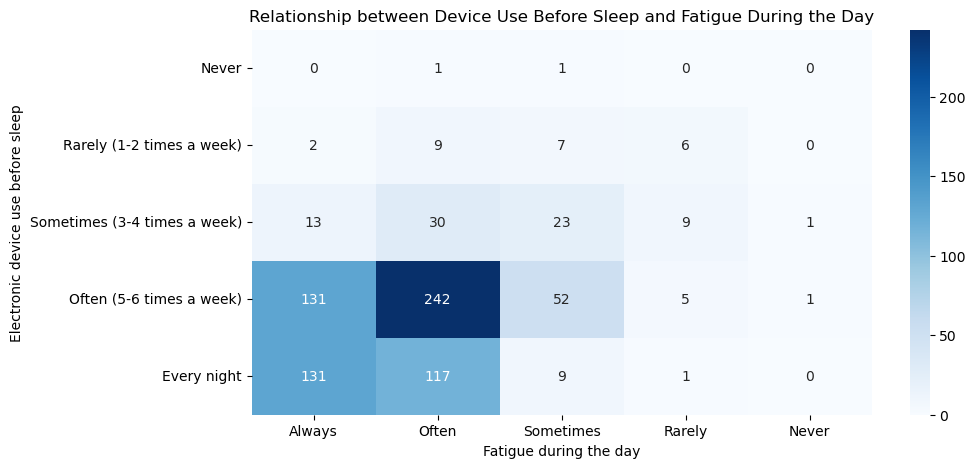

In [21]:
# Relationship between Device Use Before Sleep and Fatigue During the Day
# ordering reponse options
x_order = ["Always", "Often", "Sometimes", "Rarely", "Never"]
y_order = ["Never", "Rarely (1-2 times a week)", "Sometimes (3-4 times a week)", "Often (5-6 times a week)", "Every night"]

# picking cols 
cols = [
    "11. How often do you use electronic devices (e.g., phone, computer) before going to sleep?",
    "8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?"
]

df = sleep[cols].dropna().copy()
# converting to categorical 
df[cols[0]] = pd.Categorical(df[cols[0]], categories=y_order, ordered=True)
df[cols[1]] = pd.Categorical(df[cols[1]], categories=x_order, ordered=True)

counts = pd.crosstab(df[cols[0]], df[cols[1]])

plt.figure(figsize=(10,5))
sns.heatmap(counts, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Fatigue during the day")
plt.ylabel("Electronic device use before sleep")
plt.title("Relationship between Device Use Before Sleep and Fatigue During the Day")
plt.show()

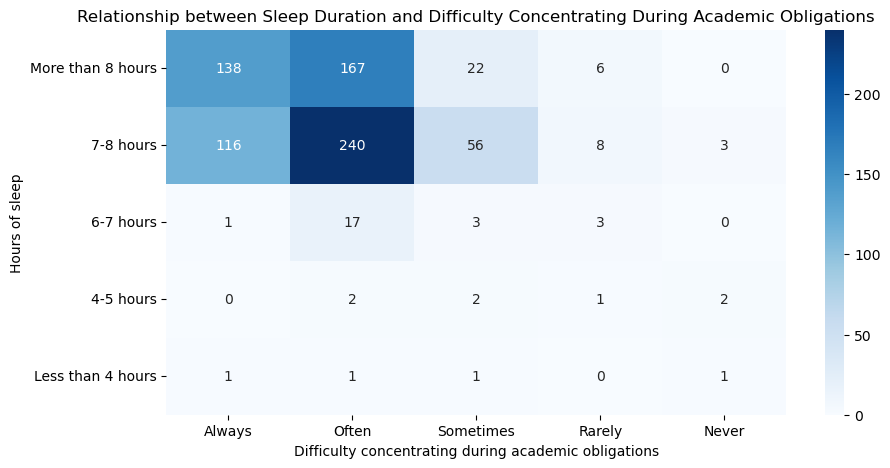

In [22]:
# Relationship between Sleep Duration and Difficulty Concentrating
x_order = ["Always", "Often", "Sometimes", "Rarely", "Never"]
y_order = ["More than 8 hours", "7-8 hours", "6-7 hours", "4-5 hours", "Less than 4 hours"]

cols = [
    "4. On average, how many hours of sleep do you get on a typical day?",
    "7. How often do you experience difficulty concentrating during lectures or studying due to lack of sleep?"
]

# dropping na vals
df = sleep[cols].dropna().copy()

# converting to categorical 
df[cols[0]] = pd.Categorical(df[cols[0]], categories=y_order, ordered=True)
df[cols[1]] = pd.Categorical(df[cols[1]], categories=x_order, ordered=True)

# contingency table
counts = pd.crosstab(df[cols[0]], df[cols[1]])

# plotting
plt.figure(figsize=(10,5))
sns.heatmap(counts, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Difficulty concentrating during academic obligations")
plt.ylabel("Hours of sleep")
plt.title("Relationship between Sleep Duration and Difficulty Concentrating During Academic Obligations")
plt.show()


### Sleep Duration and Fatigue During the Day

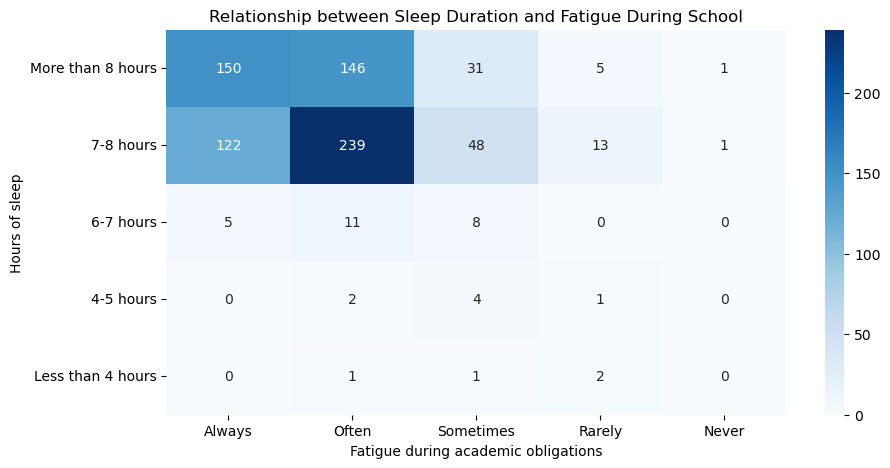

In [23]:
# Relationship between Sleep Duration and Fatigue During the Day
# ordering reponse options
x_order = ["Always", "Often", "Sometimes", "Rarely", "Never"]
y_order = ["More than 8 hours", "7-8 hours", "6-7 hours", "4-5 hours", "Less than 4 hours"]

# picking cols 
cols = [
    "4. On average, how many hours of sleep do you get on a typical day?",
    "8. How often do you feel fatigued during the day, affecting your ability to study or attend classes?"
]

# dropping na vals
df = sleep[cols].dropna().copy()
# converting to categorical 
df[cols[0]] = pd.Categorical(df[cols[0]], categories=y_order, ordered=True)
df[cols[1]] = pd.Categorical(df[cols[1]], categories=x_order, ordered=True)

# contingency table
counts = pd.crosstab(df[cols[0]], df[cols[1]])

# plotting
plt.figure(figsize=(10,5))
sns.heatmap(counts, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Fatigue during academic obligations")
plt.ylabel("Hours of sleep")
plt.title("Relationship between Sleep Duration and Fatigue During School")
plt.show()

### Sleep Duration and Academic Stress

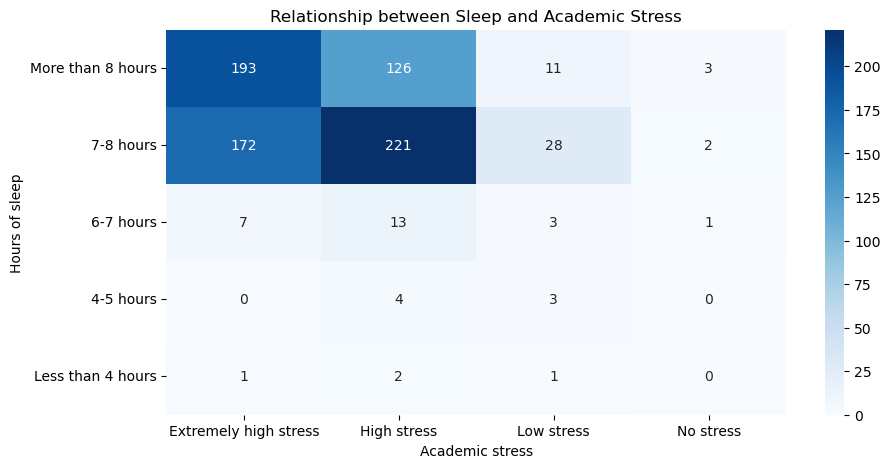

In [24]:
# Relationship between Sleep Duration and Academic Stress
# ordering reponse options
x_order = ["Extremely high stress", "High stress", "Low stress", "No stress"]
y_order = ["More than 8 hours", "7-8 hours", "6-7 hours", "4-5 hours", "Less than 4 hours"]
# picking cols 
cols = [
    "4. On average, how many hours of sleep do you get on a typical day?",
    "14. How would you describe your stress levels related to academic workload?"
]

# dropping na vals
df = sleep[cols].dropna().copy()
# converting to categorical 
df[cols[0]] = pd.Categorical(df[cols[0]], categories=y_order, ordered=True)
df[cols[1]] = pd.Categorical(df[cols[1]], categories=x_order, ordered=True)

# contingency table
counts = pd.crosstab(df[cols[0]], df[cols[1]])

# plotting
plt.figure(figsize=(10,5))
sns.heatmap(counts, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Academic stress")
plt.ylabel("Hours of sleep")
plt.title("Relationship between Sleep and Academic Stress")
plt.show()

### Waking Up at Night and Academic Stress

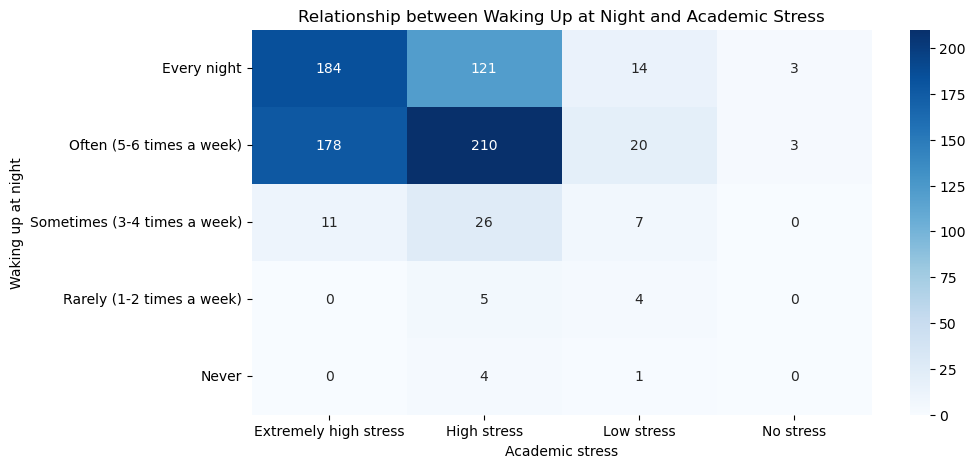

In [25]:
# Relationship between Waking Up at Night and Academic Stress
# ordering reponse options
x_order = ["Extremely high stress", "High stress", "Low stress", "No stress"]
y_order = ["Every night", "Often (5-6 times a week)", "Sometimes (3-4 times a week)", "Rarely (1-2 times a week)", "Never"]

# picking cols 
cols = [
    "5. How often do you wake up during the night and have trouble falling back asleep?",
    "14. How would you describe your stress levels related to academic workload?"
]
# dropping na vals
df = sleep[cols].dropna().copy()

# converting to categorical 
df[cols[0]] = pd.Categorical(df[cols[0]], categories=y_order, ordered=True)
df[cols[1]] = pd.Categorical(df[cols[1]], categories=x_order, ordered=True)

# contingency table
counts = pd.crosstab(df[cols[0]], df[cols[1]])

# plotting
plt.figure(figsize=(10,5))
sns.heatmap(counts, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Academic stress")
plt.ylabel("Waking up at night")
plt.title("Relationship between Waking Up at Night and Academic Stress")
plt.show()

### Sleep Quality and Academic Stress

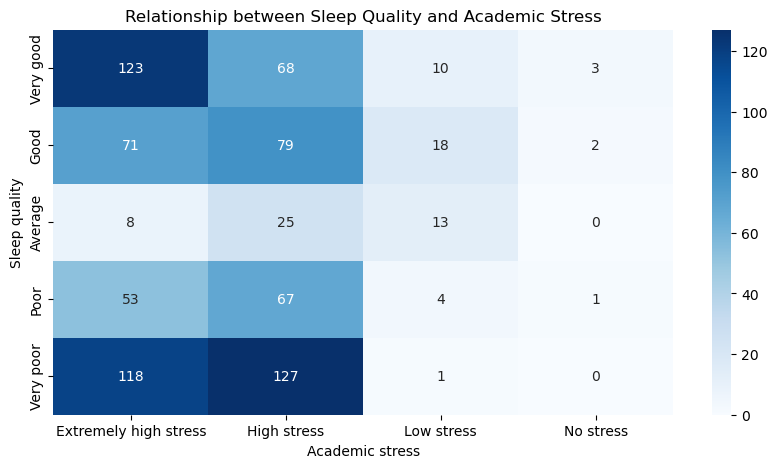

In [26]:
# Relationship between Sleep Quality and Academic Stress
# ordering reponse options
x_order = ["Extremely high stress", "High stress", "Low stress", "No stress"]
y_order = ["Very good", "Good", "Average", "Poor", "Very poor"]

# picking cols 
cols = [
    "6. How would you rate the overall quality of your sleep?",
    "14. How would you describe your stress levels related to academic workload?"
]

# dropping na vals
df = sleep[cols].dropna().copy()

# converting to categorical 
df[cols[0]] = pd.Categorical(df[cols[0]], categories=y_order, ordered=True)
df[cols[1]] = pd.Categorical(df[cols[1]], categories=x_order, ordered=True)

# contingency table
counts = pd.crosstab(df[cols[0]], df[cols[1]])

# plotting
plt.figure(figsize=(10,5))
sns.heatmap(counts, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Academic stress")
plt.ylabel("Sleep quality")
plt.title("Relationship between Sleep Quality and Academic Stress")
plt.show()

### Hours of Sleep and Sleep Quality

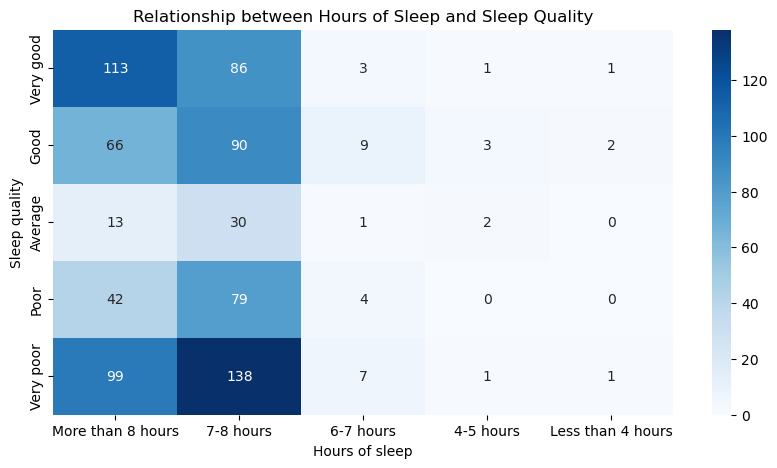

In [27]:
# Relationship between Hours of Sleep and Sleep Quality
# ordering reponse options
x_order = ["More than 8 hours", "7-8 hours", "6-7 hours", "4-5 hours", "Less than 4 hours"]
y_order = ["Very good", "Good", "Average", "Poor", "Very poor"]

# picking cols 
cols = [
    "6. How would you rate the overall quality of your sleep?",
    "4. On average, how many hours of sleep do you get on a typical day?"
]
# dropping na vals
df = sleep[cols].dropna().copy()

# converting to categorical 
df[cols[0]] = pd.Categorical(df[cols[0]], categories=y_order, ordered=True)
df[cols[1]] = pd.Categorical(df[cols[1]], categories=x_order, ordered=True)

# contingency table
counts = pd.crosstab(df[cols[0]], df[cols[1]])

# plotting
plt.figure(figsize=(10,5))
sns.heatmap(counts, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Hours of sleep")
plt.ylabel("Sleep quality")
plt.title("Relationship between Hours of Sleep and Sleep Quality")
plt.show()